Import Dataset from google drive

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Necessary Libary

In [15]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import random
from IPython import display

Data path set

In [16]:
DATA_DIR = '/content/drive/MyDrive/Data_set/archive/animals/animals'

Categories Loaded

In [17]:
def load_image(DATA_DIR):
  categories=os.listdir(DATA_DIR)
  return categories

Train Data Function

In [18]:
def get_trained_data(categories):
  trained_data=[]
  for c in categories:
    new_path=os.path.join(DATA_DIR,c)
    for img in tqdm(os.listdir(new_path)):
        label=categories.index(c)
        img_path=os.path.join(new_path,img)
        try:
          img_arr=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
          img_arr=cv2.resize(img_arr,(256,256))
        except:
          pass

        trained_data.append([img_arr,label])

  random.shuffle(trained_data)
  return trained_data

L1 Distance Calculate

In [19]:
def distance(train,valid):
  return np.sum(abs(train-valid))

Classifire Function KNN

In [20]:
def KNN(validation_set,trained_set,k=5):
  dist=[]
  zindex=0
  for v in tqdm(validation_set):

      for t in trained_set:
          d=distance(t[0],v[0])
          labell=t[1]
          dist.append([d,labell,v[1]])
      zindex +=1
  dist.sort(key=lambda x: x[0])
  return dist[:k]

Cross Validation of K-FLOD

In [21]:
def KFOLD(trained_set,kf=3,k_nei=3):
  point_dict={k_nei:[]}
  for i in range(kf):
    accuracy=0
    test=trained_set[i*(int(len(trained_set)/kf)):(i+1)*int(len(trained_set)/kf)]
    first=trained_set[0:i*int(len(trained_set)/kf)]
    last=trained_set[(i+1)*int(len(trained_set)/kf):]
    trained=first+last
    pred=KNN(test,trained,k_nei)
    print("-"*20)
    print("FOLD-",i+1)
    print(pred)
    for p in pred:
      if(p[2] == p[1]):
        accuracy +=1
    final_acc=accuracy/k_nei
    point_dict[k_nei].append(final_acc)
    print("Accuracy: ",final_acc*100,"%")

    print("-"*20)
  return point_dict

Display some image from numpy image matrix

In [22]:
def show_image(img_matrix):
  plt.figure()
  plt.imshow(img_matrix)
  plt.show()


Categories create and generate train data

In [23]:
catego=load_image(DATA_DIR)
trained_data=get_trained_data(catego)


100%|██████████| 1000/1000 [00:30<00:00, 32.30it/s]


For each value of Z-K of KNN and get the point of every K-Fold = 5

In [24]:
m=0
K_nei=[3, 5, 9, 13, 15, 20,25]
points=[]
for i in K_nei:

  print(m,"-"*20)
  point=KFOLD(trained_data,kf=5,k_nei=i)
  points.append(point)
  print("-"*7)
  m +=1



print(points)

0 --------------------


100%|██████████| 600/600 [01:26<00:00,  6.92it/s]


--------------------
FOLD- 1
[[2714301, 0, 2], [2900075, 1, 2], [2919008, 1, 2]]
Accuracy:  0.0 %
--------------------


100%|██████████| 600/600 [01:27<00:00,  6.89it/s]


--------------------
FOLD- 2
[[3194459, 2, 0], [3580760, 0, 0], [3691829, 0, 1]]
Accuracy:  33.33333333333333 %
--------------------


...

--------------------
FOLD- 3
[[3330734, 2, 0], [3612028, 0, 2], [3711652, 0, 0], [3717658, 0, 2], [3722707, 0, 0], [3781315, 2, 0], [3783124, 2, 2], [3801386, 1, 2], [3822720, 2, 0], [3838188, 2, 2], [3845682, 1, 2], [3849476, 2, 0], [3855537, 0, 1], [3872705, 2, 2], [3912546, 2, 0], [3958137, 0, 2], [4107685, 2, 1], [4108030, 2, 2], [4121468, 0, 0], [4132121, 0, 2], [4132186, 1, 2], [4139821, 0, 2], [4144197, 0, 2], [4145572, 0, 2], [4146711, 1, 0]]
Accuracy:  28.000000000000004 %
--------------------


100%|██████████| 600/600 [01:36<00:00,  6.22it/s]


--------------------
FOLD- 4
[[3735559, 2, 2], [3815157, 0, 2], [3847270, 2, 2], [3851999, 0, 2], [3856956, 2, 2], [3858177, 0, 2], [3921144, 0, 2], [3942997, 2, 2], [3966656, 0, 0], [3974035, 0, 0], [3986926, 1, 2], [4027766, 2, 2], [4070500, 2, 2], [4088425, 0, 1], [4103743, 0, 0], [4120823, 0, 2], [4149630, 0, 0], [4160268, 2, 2], [4163616, 0, 2], [4173920, 0, 2], [4178024, 0, 0], [4193696, 0, 2], [4195763, 0, 2], [4229827, 2, 2], [4230149, 0, 1]]
Accuracy:  52.0 %
--------------------


100%|██████████| 600/600 [01:30<00:00,  6.66it/s]


--------------------
FOLD- 5
[[3854285, 0, 0], [3881590, 1, 0], [3889780, 2, 0], [3892522, 2, 0], [3901620, 2, 0], [3909935, 2, 2], [3928493, 0, 0], [3946725, 0, 2], [3948104, 2, 0], [3950715, 2, 0], [3951570, 0, 0], [3958715, 2, 0], [3979497, 1, 0], [3981046, 0, 0], [4014493, 2, 2], [4028727, 0, 0], [4058141, 2, 0], [4097021, 2, 2], [4151861, 0, 0], [4170324, 0, 0], [4180533, 2, 0], [4181342, 2, 0], [4187879, 2, 0], [4200664, 0, 0], [4201803, 2, 2]]
Accuracy:  48.0 %
--------------------
-------
[{3: [0.0, 0.3333333333333333, 0.3333333333333333, 0.6666666666666666, 0.3333333333333333]}, {5: [0.2, 0.6, 0.4, 0.6, 0.2]}, {9: [0.1111111111111111, 0.6666666666666666, 0.3333333333333333, 0.5555555555555556, 0.3333333333333333]}, {13: [0.15384615384615385, 0.7692307692307693, 0.3076923076923077, 0.6153846153846154, 0.3076923076923077]}, {15: [0.13333333333333333, 0.6666666666666666, 0.3333333333333333, 0.6, 0.4]}, {20: [0.1, 0.6, 0.35, 0.55, 0.5]}, {25: [0.16, 0.52, 0.28, 0.52, 0.48]}]


Points of values plotting

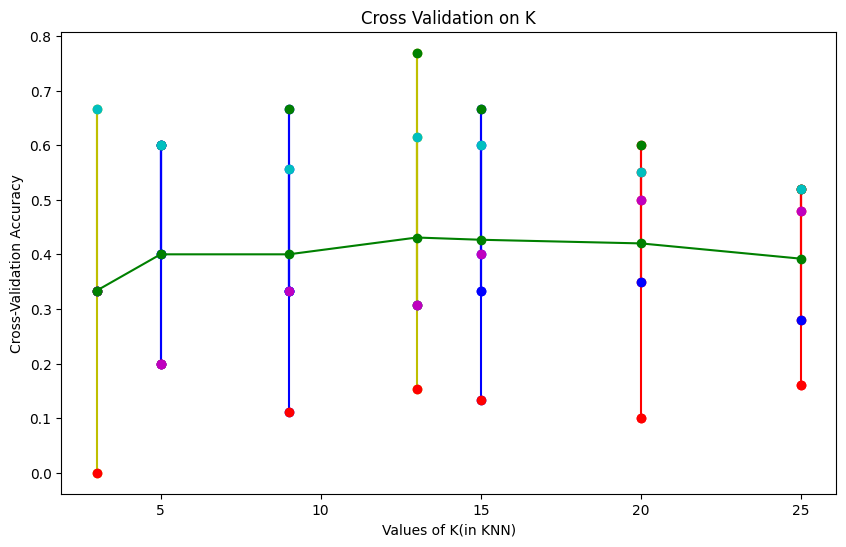

[3, 5, 9, 13, 15, 20, 25]


In [25]:
result_dict = {}
middle_point=[]

for item in points:
    result_dict.update(item)

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']
plt.figure(figsize=(10,6))
plt.title("Cross Validation on K")
plt.ylabel("Cross-Validation Accuracy")
plt.xlabel("Values of K(in KNN)")
for idx2,(key,values) in  enumerate(result_dict.items()):
  avg=np.sum(values)/len(values)
  middle_point.append(avg)
  x_values = [key] * len(values)
  plt.plot(x_values, values, marker='o', color=random.choice(colors), linestyle='-')

  for idx,val in enumerate(values):
      plt.plot(key,val,marker='o',color=colors[idx],linestyle='-')

plt.plot(K_nei,middle_point,marker='o',color='g',linestyle='-')
plt.show()
print(K_nei)